<a href="https://colab.research.google.com/github/athfizh/PemMes26_05_Hafizh/blob/main/JS06/JS06-01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---


# **Klasifikasi 2 - Lab 1**


---

---


# **Langkah 1 - Import Library**


---

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

---


# **Langkah 2 - Membuat Data Dummy**


---

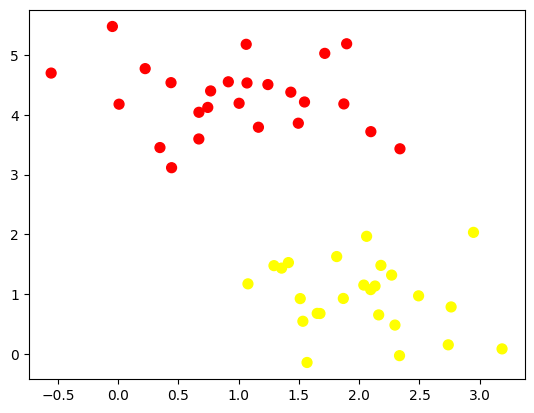

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plt.show()

> Data dummy yang dibuat terdiri dari 50 titik dengan 2 kelas (`make_blobs` dengan `cluster_std=0.60`). Kedua kelompok sudah terpisah cukup jelas, jadi data ini pas dipakai untuk melihat cara kerja SVM linier.

---


# **Langkah 3 - Buat Ilustrasi Garis Pemisah**


---

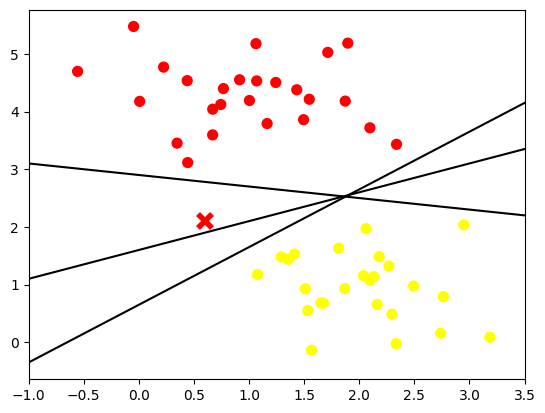

In [3]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

# data baru 'x' yang posisinya berada di antara dua kelompok
plt.plot([0.6], [2.1], 'x', color='red', markeredgewidth=4, markersize=10)

for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, '-k')

plt.xlim(-1, 3.5)
plt.show()

> Dari plot terlihat bahwa ada lebih dari satu garis lurus yang sama-sama bisa memisahkan kedua kelas dengan benar. Masalahnya, titik baru 'x' diklasifikasikan berbeda tergantung garis yang dipakai: garis pertama dan kedua menempatkannya di sisi atas, sedangkan garis ketiga menempatkannya di sisi bawah. Jadi, sekadar menemukan garis yang bisa memisahkan data saja belum cukup, kita masih perlu kriteria untuk memilih garis yang paling baik.

---


# **Langkah 4 - Ilustrasi Margin**


---

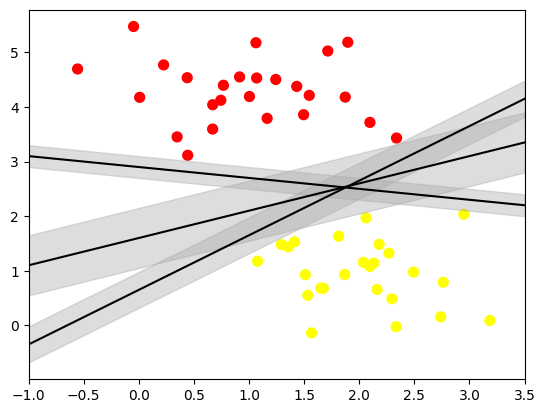

In [4]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5)
plt.show()

> Tiap garis diberi "pita" margin sampai menyentuh titik data terdekat. Garis kedua punya margin paling lebar (d = 0,55), sedangkan garis pertama (0,33) dan ketiga (0,2) lebih sempit. SVM akan memilih garis dengan margin terlebar karena jarak yang longgar ke kedua kelas membuat model lebih tahan terhadap data baru yang posisinya mepet dengan batas.

---


# **Langkah 5 - Fitting Model**


---

In [5]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

In [6]:
# buat sebuah fungsi untuk menampilkan fitting data
def plot_svc_decision_function(model, ax=None, plot_support=True):

    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # buat grid untuk evaluasi model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)

    # plot batas dan margin
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none', edgecolors='k');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

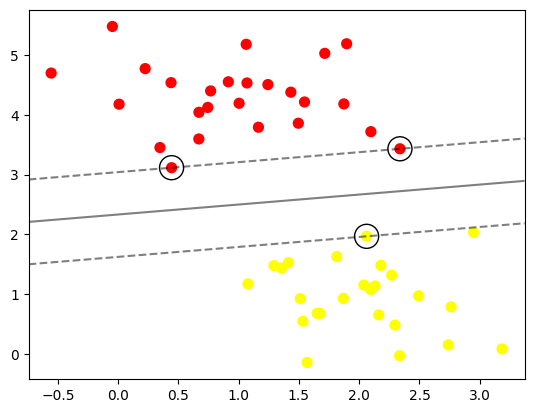

In [7]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model)
plt.show()

In [8]:
model.support_vectors_

array([[0.44359863, 3.11530945],
       [2.33812285, 3.43116792],
       [2.06156753, 1.96918596]])

> Model SVM linier dengan `C=1E10` (mendekati hard margin) menghasilkan garis pemisah dengan 3 support vector, yaitu titik yang dilingkari dan tepat berada di garis margin putus-putus. Hanya ketiga titik inilah yang menentukan posisi garis pemisah, sedangkan titik lain yang lebih jauh tidak berpengaruh.

---


# **Langkah 6 - Pengaruh Jumlah Data terhadap Model**


---

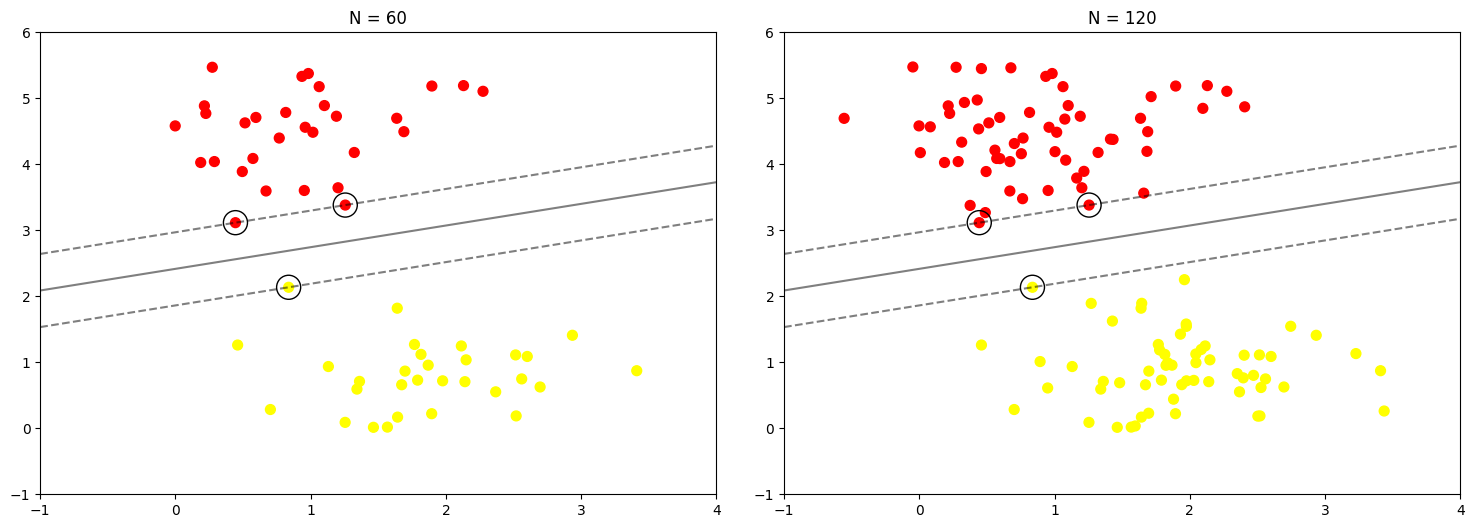

In [9]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)

    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))
plt.show()

In [10]:
# cek jumlah dan posisi support vector untuk masing-masing N
X_all, y_all = make_blobs(n_samples=200, centers=2,
                          random_state=0, cluster_std=0.60)

for N in [60, 120]:
    m = SVC(kernel='linear', C=1E10).fit(X_all[:N], y_all[:N])
    print(f'N = {N}, jumlah support vector = {len(m.support_vectors_)}')
    print(m.support_vectors_, '\n')

N = 60, jumlah support vector = 3
[[0.44359863 3.11530945]
 [1.25566754 3.38204112]
 [0.83685684 2.13635938]] 

N = 120, jumlah support vector = 3
[[0.44359863 3.11530945]
 [1.25566754 3.38204112]
 [0.83685684 2.13635938]] 



> Pada N = 60 dan N = 120, jumlah support vector sama-sama 3 dengan koordinat yang identik, sehingga garis pemisah dan margin yang terbentuk juga sama persis. Artinya, menambah data yang letaknya jauh dari margin tidak mengubah model. Model baru berubah kalau ada titik yang masuk atau mendekati area margin, karena titik itulah yang bisa menjadi support vector.

In [11]:
# jumlah data dapat dipilih di antara 10 atau 200 buah data
from ipywidgets import interact, fixed
interact(plot_svm, N=[10, 200], ax=fixed(None))

interactive(children=(Dropdown(description='N', options=(10, 200), value=10), Output()), _dom_classes=('widget…

<function __main__.plot_svm(N=10, ax=None)>

> Pada widget di atas, N = 10 dan N = 200 memang memberikan garis yang sedikit berbeda (jumlah support vector 2 untuk N = 10 dan 3 untuk N = 200). Hal ini wajar karena dengan 10 data saja belum ada titik yang cukup dekat dengan batas kedua kelas. Setelah data cukup banyak, penambahan data tidak lagi banyak berpengaruh seperti pada perbandingan N = 60 dan N = 120 sebelumnya.